# Manage original dataset

## Download dataset
original data source: https://data.mendeley.com/datasets/rscbjbr9sj/2

In [1]:
!gdown 1At_Mr4spyEmcM1ZrbEGa9SOgqHdedUI7

Downloading...
From (original): https://drive.google.com/uc?id=1At_Mr4spyEmcM1ZrbEGa9SOgqHdedUI7
From (redirected): https://drive.google.com/uc?id=1At_Mr4spyEmcM1ZrbEGa9SOgqHdedUI7&confirm=t&uuid=ac751c7a-22ae-4981-858f-7e9629c78623
To: /content/Fastwork-ChestXRay2017.zip
100% 1.24G/1.24G [00:24<00:00, 50.2MB/s]


In [2]:
!unzip -q /content/Fastwork-ChestXRay2017.zip

## Convert dataset

In [4]:
import os
import shutil
import random
from pathlib import Path
from collections import Counter

random.seed(42)
base_dir = Path('chest_xray')
output_dir = Path('chest_xray_3class_balanced')
splits = ['train', 'test']

def restructure_dataset(source_base, target_base):
    summary = {}

    # --- NEW: Print Original Data Sizes ---
    print("="*30)
    print("ORIGINAL DATASET ANALYSIS")
    print("="*30)
    for split in splits:
        print(f"[{split.upper()}] Raw Counts:")
        s_norm = len(list((source_base / split / 'NORMAL').glob('*'))) if (source_base / split / 'NORMAL').exists() else 0

        # Pneumonia sub-sorting for counts
        s_bact, s_vir = 0, 0
        p_path = source_base / split / 'PNEUMONIA'
        if p_path.exists():
            for img in p_path.glob('*'):
                if 'bacteria' in img.name.lower(): s_bact += 1
                elif 'virus' in img.name.lower(): s_vir += 1

        print(f"  - NORMAL: {s_norm}")
        print(f"  - BACTERIAL (from Pneumonia): {s_bact}")
        print(f"  - VIRAL (from Pneumonia): {s_vir}")
        print(f"  Total Raw: {s_norm + s_bact + s_vir}\n")
    # --------------------------------------

    for split in splits:
        print(f"Processing {split} split...")

        data_buckets = {'NORMAL': [], 'BACTERIAL': [], 'VIRAL': []}

        src_normal = source_base / split / 'NORMAL'
        if src_normal.exists():
            data_buckets['NORMAL'] = [img for img in src_normal.glob('*') if img.is_file()]

        src_pneumonia = source_base / split / 'PNEUMONIA'
        if src_pneumonia.exists():
            for img in src_pneumonia.glob('*'):
                if img.is_file():
                    filename = img.name.lower()
                    if 'bacteria' in filename:
                        data_buckets['BACTERIAL'].append(img)
                    elif 'virus' in filename:
                        data_buckets['VIRAL'].append(img)

        if split == 'train':
            min_size = min(len(data_buckets['NORMAL']),
                           len(data_buckets['BACTERIAL']),
                           len(data_buckets['VIRAL']))

            print(f"  [Balancing] Capping all TRAIN classes to: {min_size} images")
            for cls in data_buckets:
                data_buckets[cls] = random.sample(data_buckets[cls], min_size)

        counts = Counter()
        for cls, file_list in data_buckets.items():
            dst_path = target_base / split / cls
            dst_path.mkdir(parents=True, exist_ok=True)

            for img in file_list:
                shutil.copy2(img, dst_path / img.name)
                counts[cls] += 1

        summary[split] = counts

    return summary

stats = restructure_dataset(base_dir, output_dir)
print("\n" + "="*30)
print("BALANCED RESTRUCTURING COMPLETE")
print("="*30)

total_all = 0
for split, data in stats.items():
    split_total = sum(data.values())
    total_all += split_total
    print(f"\n[{split.upper()}]")
    for cls, count in data.items():
        print(f"  - {cls}: {count}")
    print(f"  Total {split}: {split_total}")

print(f"\nGRAND TOTAL IMAGES: {total_all}")

ORIGINAL DATASET ANALYSIS
[TRAIN] Raw Counts:
  - NORMAL: 1349
  - BACTERIAL (from Pneumonia): 2538
  - VIRAL (from Pneumonia): 1345
  Total Raw: 5232

[TEST] Raw Counts:
  - NORMAL: 234
  - BACTERIAL (from Pneumonia): 242
  - VIRAL (from Pneumonia): 148
  Total Raw: 624

Processing train split...
  [Balancing] Capping all TRAIN classes to: 1345 images
Processing test split...

BALANCED RESTRUCTURING COMPLETE

[TRAIN]
  - NORMAL: 1345
  - BACTERIAL: 1345
  - VIRAL: 1345
  Total train: 4035

[TEST]
  - NORMAL: 234
  - BACTERIAL: 242
  - VIRAL: 148
  Total test: 624

GRAND TOTAL IMAGES: 4659


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
dataset_folder = 'chest_xray_3class_balanced'
zip_name = 'chest_xray_3class_balanced.zip'
drive_destination = '/content/drive/MyDrive/'

print(f"Zipping {dataset_folder}...")
!zip -r -q {zip_name} {dataset_folder}

print(f"Uploading {zip_name} to Google Drive...")
shutil.copy(zip_name, os.path.join(drive_destination, zip_name))

print(f"Done! You can find your file at: {drive_destination}{zip_name}")

Mounted at /content/drive
Zipping chest_xray_3class_balanced...
Uploading chest_xray_3class_balanced.zip to Google Drive...
Done! You can find your file at: /content/drive/MyDrive/chest_xray_3class_balanced.zip


# Train Models

## Load 3 class dataset

original data source: https://data.mendeley.com/datasets/rscbjbr9sj/2

In [3]:
!gdown 1K9747t16KkwP9XIeu7d_uNBEeTpDzZ7p

Downloading...
From (original): https://drive.google.com/uc?id=1K9747t16KkwP9XIeu7d_uNBEeTpDzZ7p
From (redirected): https://drive.google.com/uc?id=1K9747t16KkwP9XIeu7d_uNBEeTpDzZ7p&confirm=t&uuid=f1c2e022-418a-4eb1-a0d8-141ab897678b
To: /content/Fastwork-ChestXRay2017_3class.zip
100% 1.22G/1.22G [00:14<00:00, 86.5MB/s]


In [4]:
!unzip -q Fastwork-ChestXRay2017_3class.zip

## Load 3 class dataset balanced
original data source: https://data.mendeley.com/datasets/rscbjbr9sj/2


In [12]:
!gdown 1u32nACU5MhEE3F9ZWYmjjit_gDuO2iPc

Downloading...
From (original): https://drive.google.com/uc?id=1u32nACU5MhEE3F9ZWYmjjit_gDuO2iPc
From (redirected): https://drive.google.com/uc?id=1u32nACU5MhEE3F9ZWYmjjit_gDuO2iPc&confirm=t&uuid=698f1293-469e-4653-8e35-388b0d932812
To: /content/Fastwork-ChestXRay2017_3class_balanced.zip
100% 1.13G/1.13G [00:15<00:00, 74.5MB/s]


In [13]:
!unzip -q Fastwork-ChestXRay2017_3class_balanced.zip

## Visualize function

In [3]:
import time
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, recall_score, accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame()

def evaluate_and_record(model, dataloader, model_name, device):
  model.eval()
  all_preds, all_labels = [], []

  start_time = time.time()
  with torch.no_grad():
    for inputs, labels in dataloader:
      inputs = inputs.to(device)
      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)
      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  avg_inference = ((time.time() - start_time) * 1000) / len(dataloader.dataset)

  accuracy = accuracy_score(all_labels, all_preds)
  macro_f1 = f1_score(all_labels, all_preds, average='macro')
  overall_precision = precision_score(all_labels, all_preds, average='macro')
  overall_recall = recall_score(all_labels, all_preds, average='macro')

  p_class = precision_score(all_labels, all_preds, average=None)
  r_class = recall_score(all_labels, all_preds, average=None)
  f1_class = f1_score(all_labels, all_preds, average=None)

  return {
    'Model': model_name,
    'Accuracy': accuracy,
    'Macro_F1': macro_f1,
    'Precision': overall_precision,
    'Recall': overall_recall,
    'Inference_ms': avg_inference,
    'F1_Normal': f1_class[1], 'F1_Bacterial': f1_class[0], 'F1_Viral': f1_class[2],
    'P_Normal': p_class[1], 'P_Bacterial': p_class[0], 'P_Viral': p_class[2],
    'R_Normal': r_class[1], 'R_Bacterial': r_class[0], 'R_Viral': r_class[2],
    'y_true': all_labels, 'y_pred': all_preds
  }

def evaluate_yolo_custom(model_path, dataloader, model_name):
  model = YOLO(model_path)
  all_preds = []
  all_labels = []

  start_time = time.time()

  for inputs, labels in dataloader:
    results = model(inputs, verbose=False)
    for r in results:
      all_preds.append(int(r.probs.top1))
    all_labels.extend(labels.cpu().numpy().tolist())

  end_time = time.time()
  avg_inference = ((end_time - start_time) * 1000) / len(dataloader.dataset)

  accuracy = accuracy_score(all_labels, all_preds)
  macro_f1 = f1_score(all_labels, all_preds, average='macro')
  overall_precision = precision_score(all_labels, all_preds, average='macro')
  overall_recall = recall_score(all_labels, all_preds, average='macro')

  p_class = precision_score(all_labels, all_preds, average=None)
  r_class = recall_score(all_labels, all_preds, average=None)
  f1_class = f1_score(all_labels, all_preds, average=None)

  return {
    'Model': model_name,
    'Accuracy': accuracy,
    'Macro_F1': macro_f1,
    'Precision': overall_precision,
    'Recall': overall_recall,
    'Inference_ms': avg_inference,
    'F1_Normal': f1_class[1], 'F1_Bacterial': f1_class[0], 'F1_Viral': f1_class[2],
    'P_Normal': p_class[1], 'P_Bacterial': p_class[0], 'P_Viral': p_class[2],
    'R_Normal': r_class[1], 'R_Bacterial': r_class[0], 'R_Viral': r_class[2],
    'y_true': all_labels, 'y_pred': all_preds
  }

def plot_success_metrics(df):
  sns.set_theme(style="whitegrid")
  metrics_to_plot = ['Accuracy', 'Recall', 'Macro_F1', 'Precision']

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))

  df_melted = df.melt(id_vars='Model', value_vars=metrics_to_plot, var_name='Metric', value_name='Score')
  barplot1 = sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', ax=ax1)

  for p in barplot1.patches:
    if p.get_height() > 0:
      ax1.annotate(f'{p.get_height():.2f}',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='center', xytext=(0, 8),
                  textcoords='offset points', fontsize=10, fontweight='bold')

  ax1.axhline(0.80, color='red', linestyle='--', label='Min Target (0.80)')
  ax1.set_title("Overall Performance Comparison", fontsize=16, fontweight='bold')
  ax1.set_ylim(0, 1.15)
  ax1.legend(loc='lower right')

  barplot2 = sns.barplot(data=df, x='Model', y='Inference_ms', hue='Model', palette='magma', ax=ax2, legend=False)

  for p in barplot2.patches:
    ax2.annotate(f'{p.get_height():.2f}ms',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10),
                textcoords='offset points', fontsize=11, fontweight='bold')

  ax2.set_title("Inference Latency", fontsize=16, fontweight='bold')
  plt.tight_layout()
  plt.show()

def plot_confusion_matrices(df):
  num_models = len(df)
  fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5))

  if num_models == 1:
    axes = [axes]

  classes = ['Bacterial', 'Normal', 'Viral']

  for i, (index, row) in enumerate(df.iterrows()):
    cm = confusion_matrix(row['y_true'], row['y_pred'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=classes, yticklabels=classes)

    axes[i].set_title(f"Confusion Matrix: {row['Model']}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

  plt.tight_layout()
  plt.show()

def plot_per_class_metrics(df):
  sns.set_theme(style="whitegrid")
  num_models = len(df)

  for i, (index, row) in enumerate(df.iterrows()):
    plt.figure(figsize=(10, 6))

    classes = ['Bacterial', 'Normal', 'Viral']
    metrics = ['P', 'R', 'F1']
    map_matrix = ['Precision', 'Recall', 'F1']

    plot_data = []
    for cls in classes:
      for m, mapp in zip(metrics, map_matrix):
        col_name = f"{m}_{cls}"
        if col_name in df.columns:
          plot_data.append({
            'Class': cls,
            'Metric Type': mapp,
            'Score': row[col_name]
          })

    temp_df = pd.DataFrame(plot_data)
    ax = sns.barplot(data=temp_df, x='Class', y='Score', hue='Metric Type', palette='viridis')
    ax.axhline(0.80, color='red', linestyle='--', linewidth=2, label='Target (0.80)')

    for p in ax.patches:
      if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 7),
                    textcoords='offset points', fontsize=9, fontweight='bold')

    plt.title(f"Detailed Per-Class Metrics: {row['Model']}", fontsize=15, fontweight='bold')
    plt.ylim(0, 1.15)
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    plt.show()

def plot_model_comparison(df):
  sns.set_theme(style="whitegrid")
  fig, axes = plt.subplots(2, 2, figsize=(16, 12))

  class_cols = ['F1_Normal', 'F1_Bacterial', 'F1_Viral']
  df_melted = df.melt(id_vars='Model', value_vars=class_cols, var_name='Class', value_name='F1_Score')
  sns.barplot(data=df_melted, x='Class', y='F1_Score', hue='Model', ax=axes[0, 0])
  axes[0, 0].set_title("1. Per-Class F1 Score Comparison")

  sns.barplot(data=df, x='Model', y='Recall', hue='Model', palette='viridis', legend=False, ax=axes[0, 1])
  axes[0, 1].set_title("2. Macro Recall (Higher is safer for medical)")

  sns.barplot(data=df, x='Model', y='Inference_ms', hue='Model', palette='magma', legend=False, ax=axes[1, 0])
  axes[1, 0].set_title("3. Inference Time (ms per image)")

  sns.lineplot(data=df, x='Model', y='Macro_F1', marker='o', sort=False, ax=axes[1, 1])
  axes[1, 1].set_title("4. Macro F1 Trend across Models")

  plt.tight_layout()
  plt.show()

def plot_model_comparison_with_targets(df):
  sns.set_theme(style="whitegrid")
  fig, axes = plt.subplots(2, 2, figsize=(20, 14))

  sns.barplot(data=df, x='Model', y='Macro_F1', hue='Model', palette='Blues_d', ax=axes[0, 0], legend=False)
  axes[0, 0].axhline(0.80, color='red', linestyle='--', label='Target > 0.80')
  axes[0, 0].set_title("Macro F1-Score", fontsize=14, fontweight='bold')

  sns.barplot(data=df, x='Model', y='Recall', hue='Model', palette='Greens_d', ax=axes[0, 1], legend=False)
  axes[0, 1].axhline(0.80, color='red', linestyle='--', label='Target > 0.80')
  axes[0, 1].set_title("Recall (Sensitivity)", fontsize=14, fontweight='bold')

  sns.barplot(data=df, x='Model', y='Accuracy', hue='Model', palette='Oranges_d', ax=axes[1, 0], legend=False)
  axes[1, 0].axhline(0.80, color='red', linestyle='--', label='Target > 0.80')
  axes[1, 0].set_title("Overall Accuracy", fontsize=14, fontweight='bold')

  sns.barplot(data=df, x='Model', y='Inference_ms', hue='Model', palette='magma', ax=axes[1, 1], legend=False)
  axes[1, 1].axhline(100, color='red', linestyle='--', label='Limit < 100ms')
  axes[1, 1].set_title("Inference Latency (ms)", fontsize=14, fontweight='bold')

  plt.tight_layout()
  plt.show()

def check_success_criteria(df):
  print("\n" + "="*50)
  print("SUCCESS CRITERIA VERIFICATION")
  print("="*50)

  for _, row in df.iterrows():
    print(f"\nModel: {row['Model']}")

    f1_pass = "PASS" if row['Macro_F1'] > 0.80 else "FAIL"
    recall_pass = "PASS" if row['Recall'] > 0.80 else "FAIL"
    latency_pass = "PASS" if row['Inference_ms'] < 100 else "FAIL"

    print(f"  - Macro F1 (> 0.80): {row['Macro_F1']:.4f} [{f1_pass}]")
    print(f"  - Recall   (> 0.80): {row['Recall']:.4f} [{recall_pass}]")
    print(f"  - Latency  (< 100ms): {row['Inference_ms']:.2f}ms [{latency_pass}]")

## Helper functions

In [6]:
!pip install -q -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:00


In [7]:
import torch
import gc

def clear_gpu_memory():
  """
  Completely clears the GPU VRAM and Python's memory management.
  """
  # 1. Clear PyTorch's internal cache
  if torch.cuda.is_available():
    torch.cuda.empty_cache()

  # 2. Trigger Python's Garbage Collector to remove unreferenced objects
  gc.collect()

  # 3. Synchronize to ensure all asynchronous GPU tasks are finished
  if torch.cuda.is_available():
      torch.cuda.synchronize()

  print("GPU memory cleared.")



In [8]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

def get_clean_dataloaders(data_dir, batch_size=32, img_size=640):
  data_transforms = {
    'train': transforms.Compose([
      transforms.Resize((img_size, img_size)),
      transforms.ToTensor(),
    ]),
    'val': transforms.Compose([
      transforms.Resize((img_size, img_size)),
      transforms.ToTensor(),
    ]),
    'test': transforms.Compose([
      transforms.Resize((img_size, img_size)),
      transforms.ToTensor(),
    ]),
  }

  image_datasets = {}
  for x in ['train', 'val', 'test']:
    path = os.path.join(data_dir, x)
    if not os.path.exists(path):
      raise FileNotFoundError(f"Directory not found: {path}. Please run the split script first.")
    image_datasets[x] = datasets.ImageFolder(path, data_transforms[x])

  loaders = {
    x: DataLoader(
      image_datasets[x],
      batch_size=batch_size,
      shuffle=(x == 'train'),
      num_workers=2,
      pin_memory=True if torch.cuda.is_available() else False
    )
    for x in ['train', 'val', 'test']
  }

  dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
  class_names = image_datasets['train'].classes

  print(f"Dataset Details:")
  print(f"  Classes: {class_names}")
  for x in ['train', 'val', 'test']:
    print(f"  {x.capitalize()} size: {dataset_sizes[x]} images")

  return loaders, dataset_sizes, class_names

def initialize_model(model_name, num_classes=3):
    if model_name == "mobilenet_v3":
        model = models.mobilenet_v3_large(weights='DEFAULT')
        # Increase dropout to 0.4 or 0.5
        num_ftrs = model.classifier[3].in_features
        model.classifier[3] = nn.Sequential(
            nn.Dropout(p=0.4), # Added heavy dropout
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == "efficientnet_v2":
        model = models.efficientnet_v2_s(weights='DEFAULT')
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Dropout(p=0.4), # Added heavy dropout
            nn.Linear(num_ftrs, num_classes)
        )
    return model

## Train, Validate and Test Function

In [11]:
import os
import random
import shutil
from pathlib import Path

def create_val_split(root_path, val_ratio=0.2, seed=42):
  random.seed(seed)
  root = Path(root_path)
  train_dir = root / 'train'
  val_dir = root / 'val'

  if val_dir.exists():
    print("Validation folder already exists. Skipping split.")
    return

  print(f"Creating validation split ({val_ratio*100}%) from {train_dir}...")

  for class_folder in train_dir.iterdir():
    if class_folder.is_dir():
      (val_dir / class_folder.name).mkdir(parents=True, exist_ok=True)

      images = list(class_folder.glob('*'))
      random.shuffle(images)

      val_count = int(len(images) * val_ratio)
      val_images = images[:val_count]

      for img in val_images:
        shutil.move(str(img), str(val_dir / class_folder.name / img.name))

  print("Split complete. Folder structure is now: train, val, test.")

create_val_split('chest_xray_3class')
create_val_split('chest_xray_3class_balanced')

Validation folder already exists. Skipping split.
Validation folder already exists. Skipping split.


In [9]:
import os
import copy
import torch

def train_pytorch_model(model, dataloaders, dataset_sizes, criterion, optimizer, scheduler,
                        model_name="best_model", num_epochs=25, device='cuda', patience=5):
  since = time.time()
  best_model_wts = copy.deepcopy(model.state_dict())
  best_loss = float('inf')

  early_stop_counter = 0
  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

  # Create a directory for weights if it doesn't exist
  os.makedirs('weights', exist_ok=True)
  save_path = f'weights/{model_name}.pth'

  for epoch in range(num_epochs):
    print(f'Epoch {epoch}/{num_epochs - 1}')
    print('-' * 10)

    for phase in ['train', 'val']:
      if phase == 'train':
          model.train()
      else:
          model.eval()

      running_loss = 0.0
      running_corrects = 0

      for inputs, labels in dataloaders[phase]:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.set_grad_enabled(phase == 'train'):
          outputs = model(inputs)
          _, preds = torch.max(outputs, 1)
          loss = criterion(outputs, labels)

          if phase == 'train':
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

      epoch_loss = running_loss / dataset_sizes[phase]
      epoch_acc = running_corrects.double() / dataset_sizes[phase]

      history[f'{phase}_loss'].append(epoch_loss)
      history[f'{phase}_acc'].append(epoch_acc.item())

      print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

      if phase == 'val':
        scheduler.step(epoch_loss)

        if epoch_loss < best_loss:
          print(f"Val loss decreased ({best_loss:.4f} --> {epoch_loss:.4f}). Saving weights to {save_path}")
          best_loss = epoch_loss
          best_model_wts = copy.deepcopy(model.state_dict())

          torch.save(best_model_wts, save_path)

          early_stop_counter = 0
        else:
          early_stop_counter += 1
          print(f"EarlyStopping counter: {early_stop_counter} out of {patience}")

    print()
    if early_stop_counter >= patience:
      print("Early stopping triggered.")
      break

  # Finalize
  model.load_state_dict(best_model_wts)
  return model, history

## Hyperparameters

In [10]:
DATA_PATH = 'chest_xray_3class_balanced'
img_zise = 640
batch_size = 16

try:
  dataloaders, sizes, classes = get_clean_dataloaders(DATA_PATH, batch_size=batch_size, img_size=img_zise)
  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  print(f"\nUsing device: {device}")
except Exception as e:
  print(f"Error: {e}")

Dataset Details:
  Classes: ['BACTERIAL', 'NORMAL', 'VIRAL']
  Train size: 3228 images
  Val size: 807 images
  Test size: 624 images

Using device: cpu


In [ ]:
import pandas as pd
from ultralytics import YOLO
import torch.optim as optim
from torch.optim import lr_scheduler


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 70
lr = 1e-4
patience = 12

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Train MobileNet

In [ ]:

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
model_mobilenet = initialize_model("mobilenet_v3", num_classes=3).to(device)
optimizer = optim.Adam(model_mobilenet.parameters(), lr=lr)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=5)

history_logs = {}

# --- MODEL 1 MobileNet-V3 ---
print("Training MobileNet-V3...")
model_mobilenet, hist_mobile = train_pytorch_model(
    model_mobilenet, dataloaders, sizes, criterion, optimizer, scheduler,
    num_epochs=num_epochs, device=device, patience=patience, model_name="mobilenet_v3"
)
df_mobile = pd.DataFrame(hist_mobile)
history_logs['MobileNet-V3'] = df_mobile

Training MobileNet-V3...
Epoch 0/69
----------
Train Loss: 0.6858 Acc: 0.7650
Val Loss: 0.9906 Acc: 0.5703
Val loss decreased (inf --> 0.9906). Saving weights to weights/mobilenet_v3.pth

Epoch 1/69
----------
Train Loss: 0.5809 Acc: 0.8302
Val Loss: 0.8384 Acc: 0.6823
Val loss decreased (0.9906 --> 0.8384). Saving weights to weights/mobilenet_v3.pth

Epoch 2/69
----------
Train Loss: 0.5299 Acc: 0.8591
Val Loss: 0.7746 Acc: 0.6794
Val loss decreased (0.8384 --> 0.7746). Saving weights to weights/mobilenet_v3.pth

Epoch 3/69
----------
Train Loss: 0.4768 Acc: 0.8997
Val Loss: 0.7231 Acc: 0.7311
Val loss decreased (0.7746 --> 0.7231). Saving weights to weights/mobilenet_v3.pth

Epoch 4/69
----------
Train Loss: 0.4123 Acc: 0.9343
Val Loss: 0.6604 Acc: 0.7866
Val loss decreased (0.7231 --> 0.6604). Saving weights to weights/mobilenet_v3.pth

Epoch 5/69
----------
Train Loss: 0.3541 Acc: 0.9764
Val Loss: 0.6804 Acc: 0.8038
EarlyStopping counter: 1 out of 12

Epoch 6/69
----------
Train Lo

In [ ]:
from google.colab import drive
import os
import shutil

df_mobile.to_csv('mobilenet_v3_history.csv', index=False)
drive_destination = '/content/drive/MyDrive/fastwork/CXR-Pneumonia-results/trained_original_data'

os.makedirs(drive_destination, exist_ok=True)

print(f"Uploading to Google Drive...")

history_file_path = "/content/mobilenet_v3_history.csv"
weights_file_path = "/content/weights/mobilenet_v3.pth"

if os.path.exists(history_file_path):
    shutil.copy(history_file_path, os.path.join(drive_destination, "mobilenet_v3_history.csv"))
    print(f"Copied {history_file_path} to Google Drive.")
else:
    print(f"Warning: {history_file_path} not found. Skipping copy.")

if os.path.exists(weights_file_path):
    shutil.copy(weights_file_path, os.path.join(drive_destination, "mobilenet_v3.pth"))
    print(f"Copied {weights_file_path} to Google Drive.")
else:
    print(f"Warning: {weights_file_path} not found. Skipping copy.")

print(f"Done!")

Uploading to Google Drive...
Copied /content/mobilenet_v3_history.csv to Google Drive.
Copied /content/weights/mobilenet_v3.pth to Google Drive.
Done!


In [ ]:

del model_mobilenet
del optimizer
del scheduler

clear_gpu_memory()

NameError: name 'model_mobilenet' is not defined

## Train EfficientNet

In [ ]:
# --- MODEL 2 EfficientNet-V2 ---
DATA_PATH = 'chest_xray_3class_balanced'
img_zise = 640
batch_size = 16

try:
  dataloaders, sizes, classes = get_clean_dataloaders(DATA_PATH, batch_size=batch_size, img_size=img_zise)
  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  print(f"\nUsing device: {device}")
except Exception as e:
  print(f"Error: {e}")

print("\nTraining EfficientNet-V2...")
model_effnet = initialize_model("efficientnet_v2", num_classes=3).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model_effnet.parameters(), lr=lr)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=5)

model_effnet, hist_eff = train_pytorch_model(
    model_effnet, dataloaders, sizes, criterion, optimizer, scheduler,
    num_epochs=num_epochs, device=device, patience=patience, model_name="efficientnet_v2"
)
df_effnet = pd.DataFrame(hist_eff)
history_logs['EfficientNet-V2'] = df_effnet



Dataset Details:
  Classes: ['BACTERIAL', 'NORMAL', 'VIRAL']
  Train size: 4187 images
  Val size: 1045 images
  Test size: 624 images

Using device: cuda:0

Training EfficientNet-V2...
Epoch 0/69
----------
Train Loss: 0.6752 Acc: 0.7774
Val Loss: 0.5930 Acc: 0.8239
Val loss decreased (inf --> 0.5930). Saving weights to weights/efficientnet_v2.pth

Epoch 1/69
----------
Train Loss: 0.5678 Acc: 0.8390
Val Loss: 0.5897 Acc: 0.8115
Val loss decreased (0.5930 --> 0.5897). Saving weights to weights/efficientnet_v2.pth

Epoch 2/69
----------
Train Loss: 0.4984 Acc: 0.8825
Val Loss: 0.5857 Acc: 0.8249
Val loss decreased (0.5897 --> 0.5857). Saving weights to weights/efficientnet_v2.pth

Epoch 3/69
----------
Train Loss: 0.4107 Acc: 0.9432
Val Loss: 0.6348 Acc: 0.8220
EarlyStopping counter: 1 out of 12

Epoch 4/69
----------
Train Loss: 0.3677 Acc: 0.9670
Val Loss: 0.6032 Acc: 0.8230
EarlyStopping counter: 2 out of 12

Epoch 5/69
----------
Train Loss: 0.3484 Acc: 0.9733
Val Loss: 0.6460 Acc:

In [ ]:
from google.colab import drive
import os
import shutil

df_effnet.to_csv('efficientnet_v2_history.csv', index=False)

# drive.mount('/content/drive')
drive_destination = '/content/drive/MyDrive/fastwork/CXR-Pneumonia-results/trained_original_data'

os.makedirs(drive_destination, exist_ok=True)

print(f"Uploading to Google Drive...")

history_file_path = "/content/efficientnet_v2_history.csv"
weights_file_path = "/content/weights/efficientnet_v2.pth"

if os.path.exists(history_file_path):
    shutil.copy(history_file_path, os.path.join(drive_destination, "efficientnet_v2_history.csv"))
    print(f"Copied {history_file_path} to Google Drive.")
else:
    print(f"Warning: {history_file_path} not found. Skipping copy.")

if os.path.exists(weights_file_path):
    shutil.copy(weights_file_path, os.path.join(drive_destination, "efficientnet_v2.pth"))
    print(f"Copied {weights_file_path} to Google Drive.")
else:
    print(f"Warning: {weights_file_path} not found. Skipping copy.")

print(f"Done!")

Uploading to Google Drive...
Copied /content/efficientnet_v2_history.csv to Google Drive.
Copied /content/weights/efficientnet_v2.pth to Google Drive.
Done!


In [ ]:
del model_effnet
del optimizer
del scheduler

clear_gpu_memory()

GPU memory cleared.


## Train YOLO

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# --- MODEL 3 YOLO11-cls ---
print("\nTraining YOLO...")
model_yolo = YOLO('yolo11n-cls.pt')
results_yolo = model_yolo.train(data=DATA_PATH, epochs=num_epochs, imgsz=img_zise,
                                device=device, patience=patience, name='yolo_pneumonia1')

# # Load YOLO's automatic CSV log and standardize it
# yolo_csv_path = 'runs/classify/yolo_pneumonia/results.csv'
# yolo_raw = pd.read_csv(yolo_csv_path)

# # Standardize YOLO columns to match PyTorch [train_loss, train_acc, val_loss, val_acc]
# df_yolo = pd.DataFrame({
#     'train_loss': yolo_raw['train/loss'].values,
#     'train_acc':  yolo_raw['metrics/accuracy_top1'].values, # YOLO calls accuracy top1
#     'val_loss':   yolo_raw['val/loss'].values,
#     'val_acc':    yolo_raw['metrics/accuracy_top1'].values # Usually matches top1 during val
# })
# history_logs['YOLO11'] = df_yolo


Training YOLO...
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chest_xray_3class, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_pneumonia1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=12, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, pro

In [ ]:
from google.colab import drive
import os
import shutil


# drive.mount('/content/drive')
drive_destination = '/content/drive/MyDrive/fastwork/CXR-Pneumonia-results/trained_original_data'

os.makedirs(drive_destination, exist_ok=True)

print(f"Uploading to Google Drive...")

history_file_path = "runs/classify/yolo_pneumonia1/results.csv"
weights_file_path = "/content/runs/classify/yolo_pneumonia1/weights/best.pt"

if os.path.exists(history_file_path):
    shutil.copy(history_file_path, os.path.join(drive_destination, "yolov11_history.csv"))
    print(f"Copied {history_file_path} to Google Drive.")
else:
    print(f"Warning: {history_file_path} not found. Skipping copy.")

if os.path.exists(weights_file_path):
    shutil.copy(weights_file_path, os.path.join(drive_destination, "yolov11_best.pt"))
    print(f"Copied {weights_file_path} to Google Drive.")
else:
    print(f"Warning: {weights_file_path} not found. Skipping copy.")

print(f"Done!")

Uploading to Google Drive...
Copied runs/classify/yolo_pneumonia1/results.csv to Google Drive.
Copied /content/runs/classify/yolo_pneumonia1/weights/best.pt to Google Drive.
Done!


In [ ]:
model_yolo = YOLO('yolo26n-cls.pt')
results_yolo = model_yolo.train(data=DATA_PATH, epochs=num_epochs, imgsz=img_zise,
                                device=device, patience=patience, name='yolo_pneumonia2')

drive_destination = '/content/drive/MyDrive/fastwork/CXR-Pneumonia-results/trained_original_data'

os.makedirs(drive_destination, exist_ok=True)

print(f"Uploading to Google Drive...")

history_file_path = "runs/classify/yolo_pneumonia2/results.csv"
weights_file_path = "/content/runs/classify/yolo_pneumonia2/weights/best.pt"

if os.path.exists(history_file_path):
    shutil.copy(history_file_path, os.path.join(drive_destination, "yolov26_history.csv"))
    print(f"Copied {history_file_path} to Google Drive.")
else:
    print(f"Warning: {history_file_path} not found. Skipping copy.")

if os.path.exists(weights_file_path):
    shutil.copy(weights_file_path, os.path.join(drive_destination, "yolov26_best.pt"))
    print(f"Copied {weights_file_path} to Google Drive.")
else:
    print(f"Warning: {weights_file_path} not found. Skipping copy.")

print(f"Done!")

engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chest_xray_3class, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_pneumonia2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=12, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=Fa

# Evaluation and Visualization

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
from ultralytics import YOLO

DATA_PATH = 'chest_xray_3class'
root_model_path = '/content/drive/MyDrive/fastwork/CXR-Pneumonia-results/trained_original_data'
img_zise = 640
batch_size = 16

try:
  dataloaders, sizes, classes = get_clean_dataloaders(DATA_PATH, batch_size=batch_size, img_size=img_zise)
  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  print(f"\nUsing device: {device}")
except Exception as e:
  print(f"Error: {e}")

all_model_results = []

# --- Evaluate MobileNet-V3 ---
print("Evaluating MobileNet-V3...")
model_mobile = initialize_model("mobilenet_v3", num_classes=3)
model_mobile.load_state_dict(torch.load(os.path.join(root_model_path, 'mobilenet_v3.pth')))
model_mobile.to(device)

res_mobile = evaluate_and_record(model_mobile, dataloaders['test'], "MobileNet-V3", device)
all_model_results.append(res_mobile)
clear_gpu_memory()

# --- Evaluate EfficientNet-V2 ---
print("Evaluating EfficientNet-V2...")
model_eff = initialize_model("efficientnet_v2", num_classes=3)
model_eff.load_state_dict(torch.load(os.path.join(root_model_path, 'efficientnet_v2.pth')))
model_eff.to(device)

res_eff = evaluate_and_record(model_eff, dataloaders['test'], "EfficientNet-V2", device)
all_model_results.append(res_eff)
clear_gpu_memory()

# --- Evaluate YOLO ---
print("Evaluating YOLO11...")
yolo_path = os.path.join(root_model_path, 'yolov11_best.pt')
res_yolo = evaluate_yolo_custom(yolo_path, dataloaders['test'], "YOLO11n")
all_model_results.append(res_yolo)

print("Evaluating YOLO26...")
yolo_path = os.path.join(root_model_path, 'yolov26_best.pt')
res_yolo = evaluate_yolo_custom(yolo_path, dataloaders['test'], "YOLO26n")
all_model_results.append(res_yolo)

# --- Final Results ---
final_df = pd.DataFrame(all_model_results)
print("\nFinal Benchmark Table:")
# display(final_df)

Dataset Details:
  Classes: ['BACTERIAL', 'NORMAL', 'VIRAL']
  Train size: 4187 images
  Val size: 1045 images
  Test size: 624 images

Using device: cuda:0
Evaluating MobileNet-V3...
GPU memory cleared.
Evaluating EfficientNet-V2...
GPU memory cleared.
Evaluating YOLO11...
Evaluating YOLO26...

Final Benchmark Table:


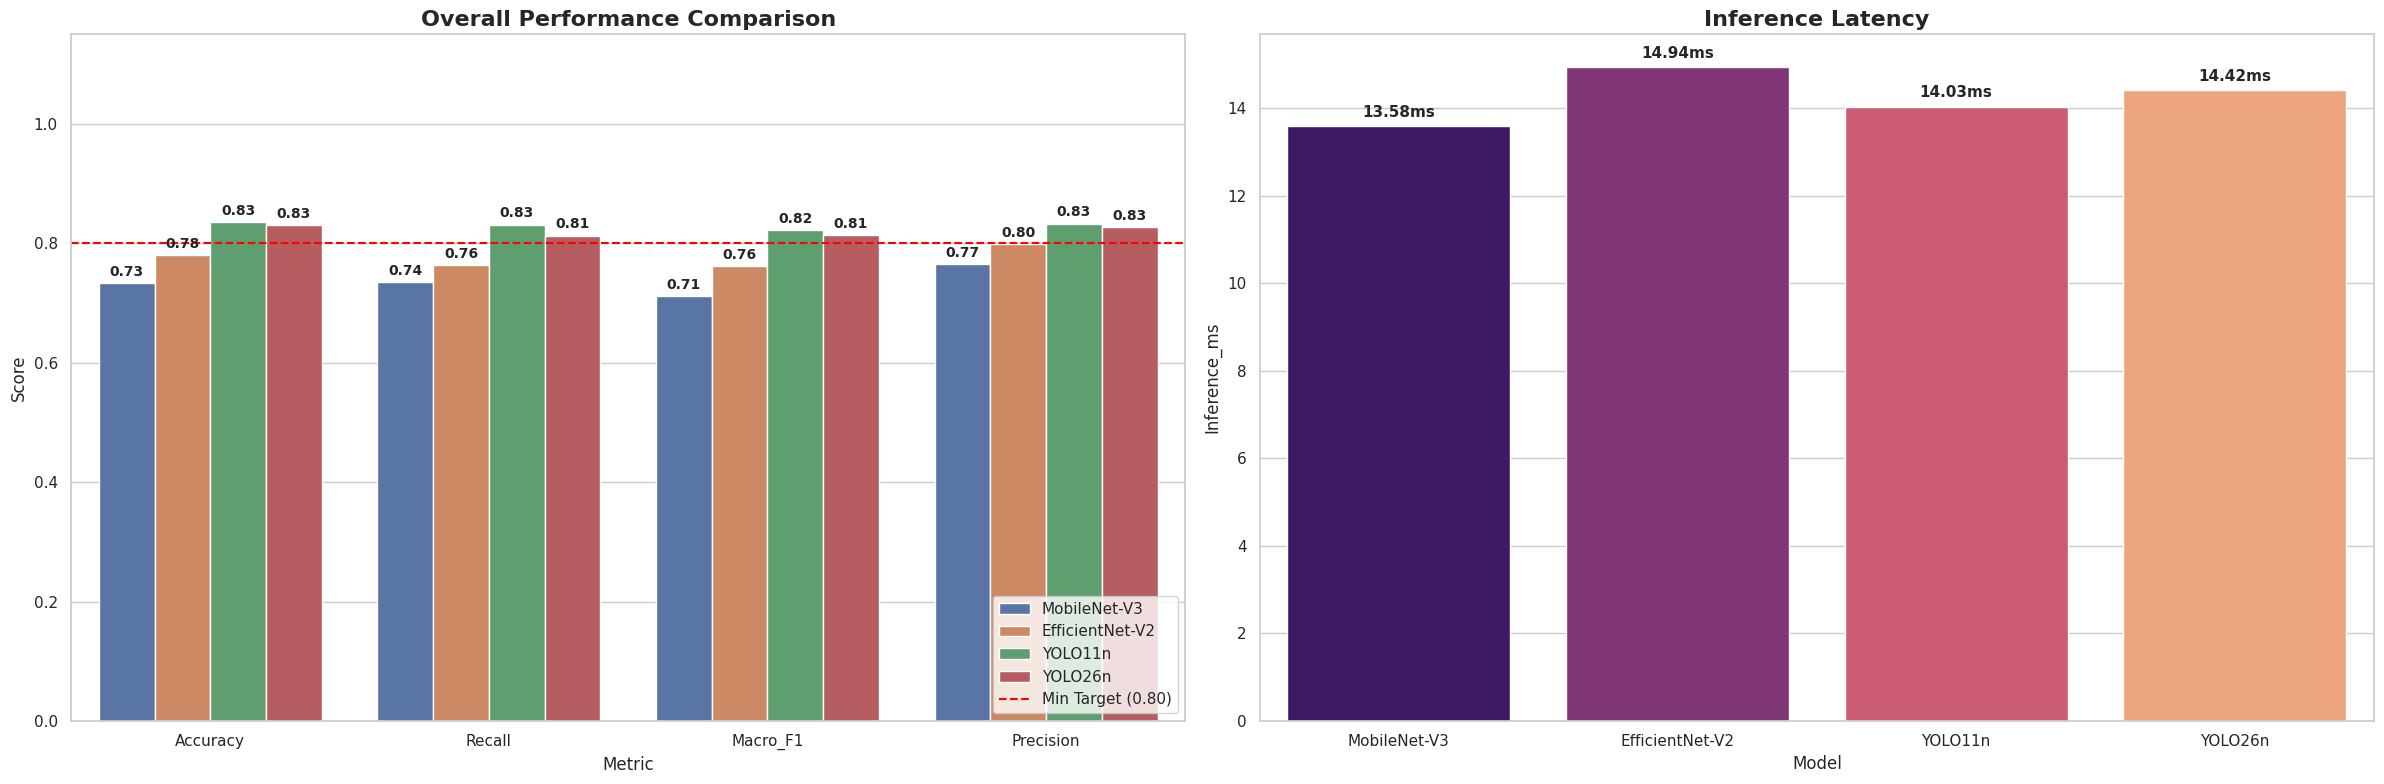

In [22]:
plot_success_metrics(final_df)

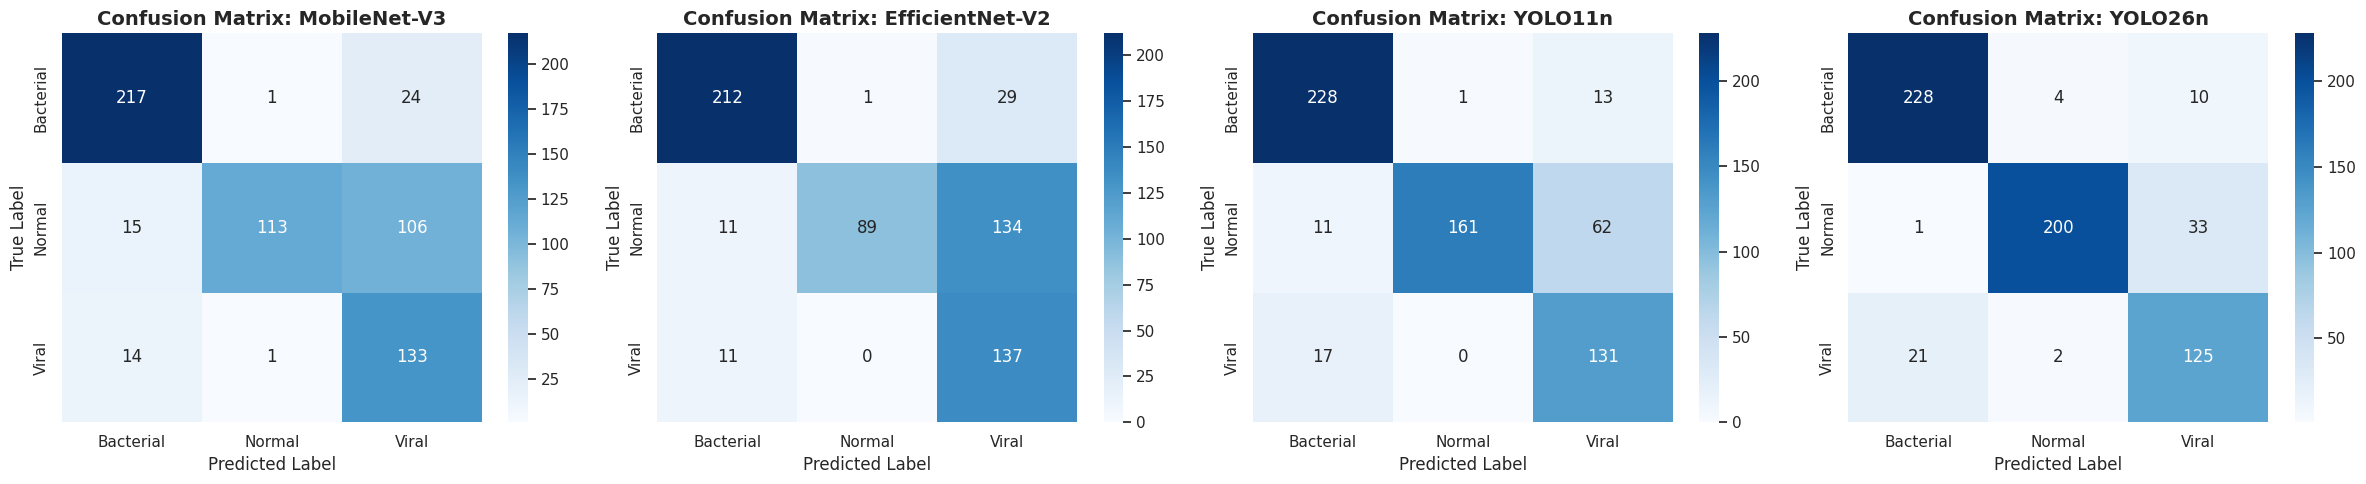

In [11]:
import ast
import re

def parse_string_to_list(s):
  if not isinstance(s, str):
    return s
  try:
    return ast.literal_eval(s)
  except (ValueError, SyntaxError):
    cleaned_s = re.sub(r'np\.int64\((.*?)\)', r'\1', s)

    cleaned_s = cleaned_s.strip()
    if cleaned_s.startswith('array(') and cleaned_s.endswith(')'):
      cleaned_s = cleaned_s[len('array('):-1].strip()

    cleaned_s = cleaned_s.strip('[]')
    cleaned_s = cleaned_s.replace(',', ' ')

    try:
      return [int(x) for x in cleaned_s.split() if x.strip()]
    except ValueError:
      raise ValueError(f"Could not parse string as list of integers: '{s}'")

# Convert string representations of lists back to actual lists
test_df['y_true'] = test_df['y_true'].apply(parse_string_to_list)
test_df['y_pred'] = test_df['y_pred'].apply(parse_string_to_list)

plot_confusion_matrices(test_df)

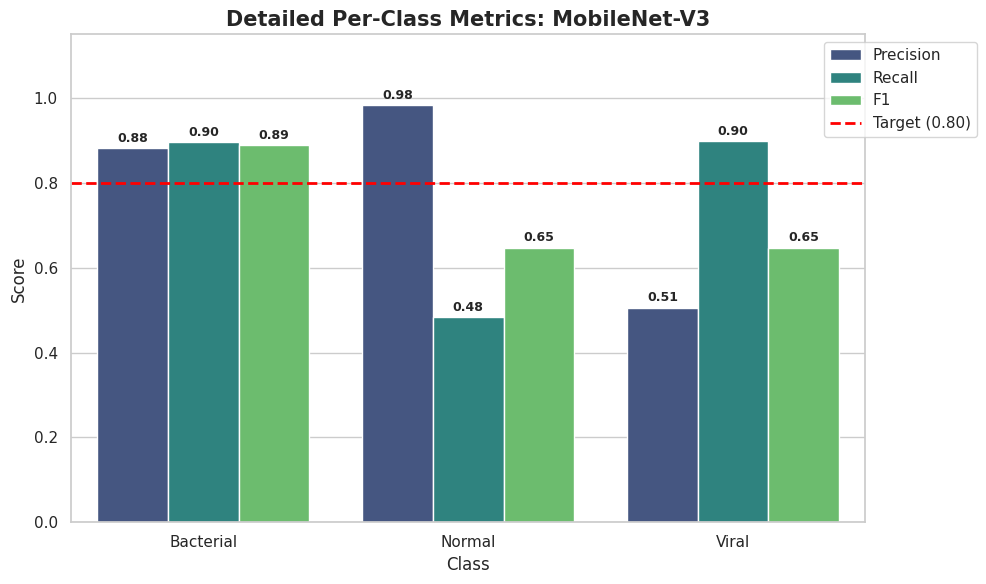

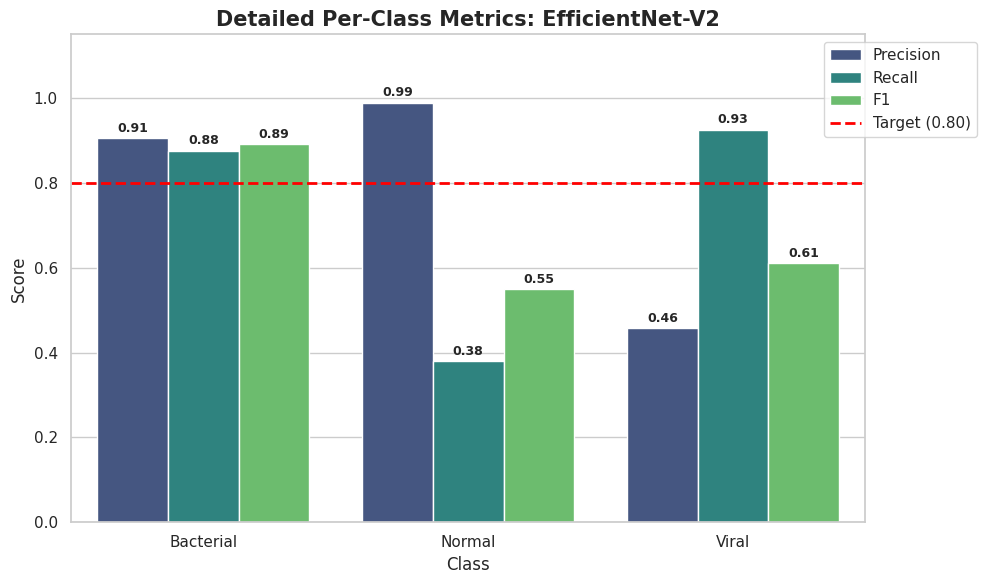

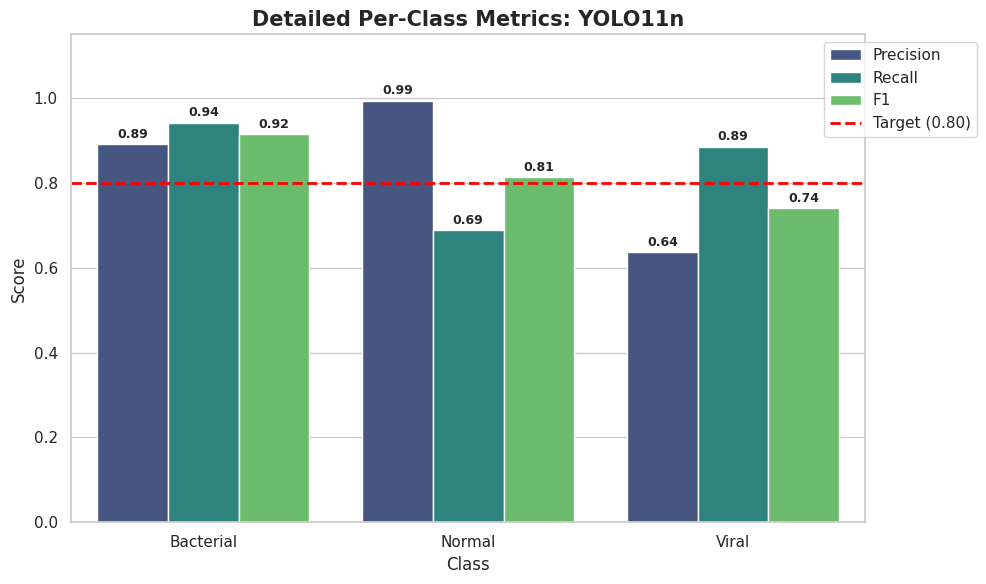

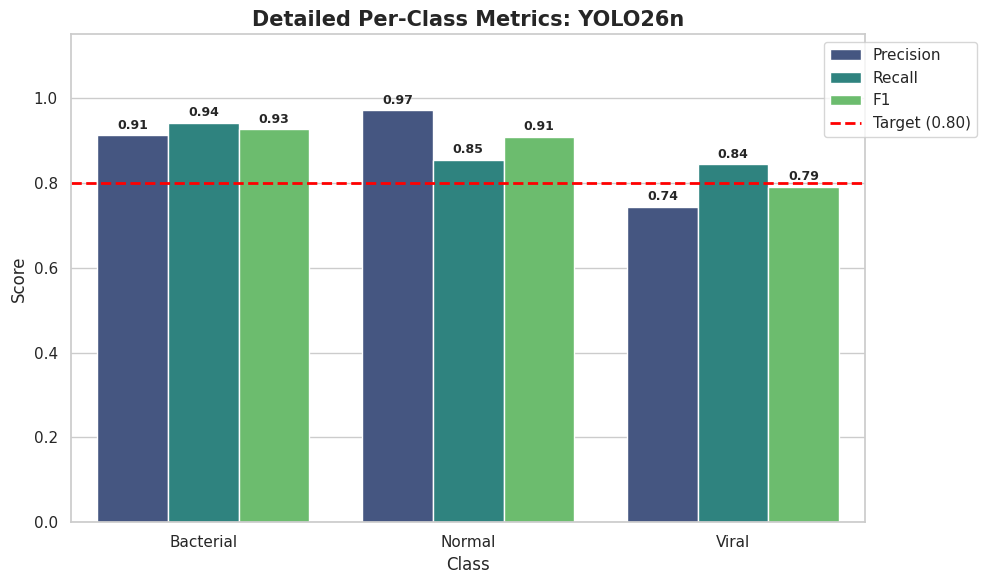

In [6]:
import os

root_model_path = '/content/drive/MyDrive/fastwork/CXR-Pneumonia-results/trained_balanced_data'
test_df = pd.read_csv(os.path.join(root_model_path, 'final_eval_results.csv'))
plot_per_class_metrics(test_df)

In [24]:
# final_eval_results.csv
final_df.to_csv('final_eval_results.csv', index=False)
# save to drive
os.makedirs(root_model_path, exist_ok=True)
shutil.copy('final_eval_results.csv', os.path.join(root_model_path, "final_eval_results.csv"))


'/content/drive/MyDrive/fastwork/CXR-Pneumonia-results/trained_original_data/final_eval_results.csv'